In [1]:
import os
import time
import string

import numpy as np
import pandas as pd

from datetime import datetime, timedelta
from collections import Counter

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.dates as mdates

from tqdm import tqdm

# Font
from matplotlib import font_manager
font_path = "/workspace/KENTECH/fonts/"
font_list = os.listdir(font_path)
for font_file in font_list:
    try:
        font_manager.fontManager.addfont(font_path + font_file)
    except:
        raise Exception(f"Cannot Load {font_path+font_file}")

plt.rcParams["figure.dpi"] = 300

# Handling the DB

In [832]:
import sys
sys.path.append( '/workspace/KISTI_DB_Manager/' )

from KISTI_DB_Manager import manage, preview, processing, plot
import importlib as imp
imp.reload(manage), imp.reload(preview), imp.reload(processing), imp.reload(plot)

plt.rcParams["figure.dpi"] = 300

# WOS

In [3]:
path = '/workspace/share/Data-HDD/Web of Science/Web of Science (2024)/annual/'
flist = sorted([x for x in os.listdir(path) if x[0] != '.'])

In [10]:
f = flist[1]

def WOS_extract_jsons(path, f):
    import zipfile
    import gzip
    import json
    
    with zipfile.ZipFile(path+f, 'r') as zip_ref:
        # List all contents of the ZIP file, assuming there's only one gz file inside
        gz_file_name = [f for f in zip_ref.namelist() if f.endswith('.gz')][0]
        
        # Extract the gz file content
        with zip_ref.open(gz_file_name) as gz_file:
            # Use gzip on the extracted file-like object
            with gzip.open(gz_file, 'rt') as json_file:  # 'rt' mode for text mode reading
                content = json_file.read()
                # extracted_dict = json.load(json_file)
    xml = processing.read_a_xml(content)
    jsons = xml['records.REC'] # Real Record part
    return jsons

jsons = WOS_extract_jsons(path, f)

In [606]:
index_key = 'UID'
except_keys = ['dynamic_data'] # exception part for unstructured json branches

df, df_subs, excepted_part = processing.extract_data_from_jsons(jsons[:], index_key, except_keys)

100%|████████████████████████████████████| 51166/51166 [01:51<00:00, 460.33it/s]


In [607]:
df_subs.keys()

dict_keys(['static_data__summary__titles__title', 'static_data__fullrecord_metadata__category_info__subjects__subject'])

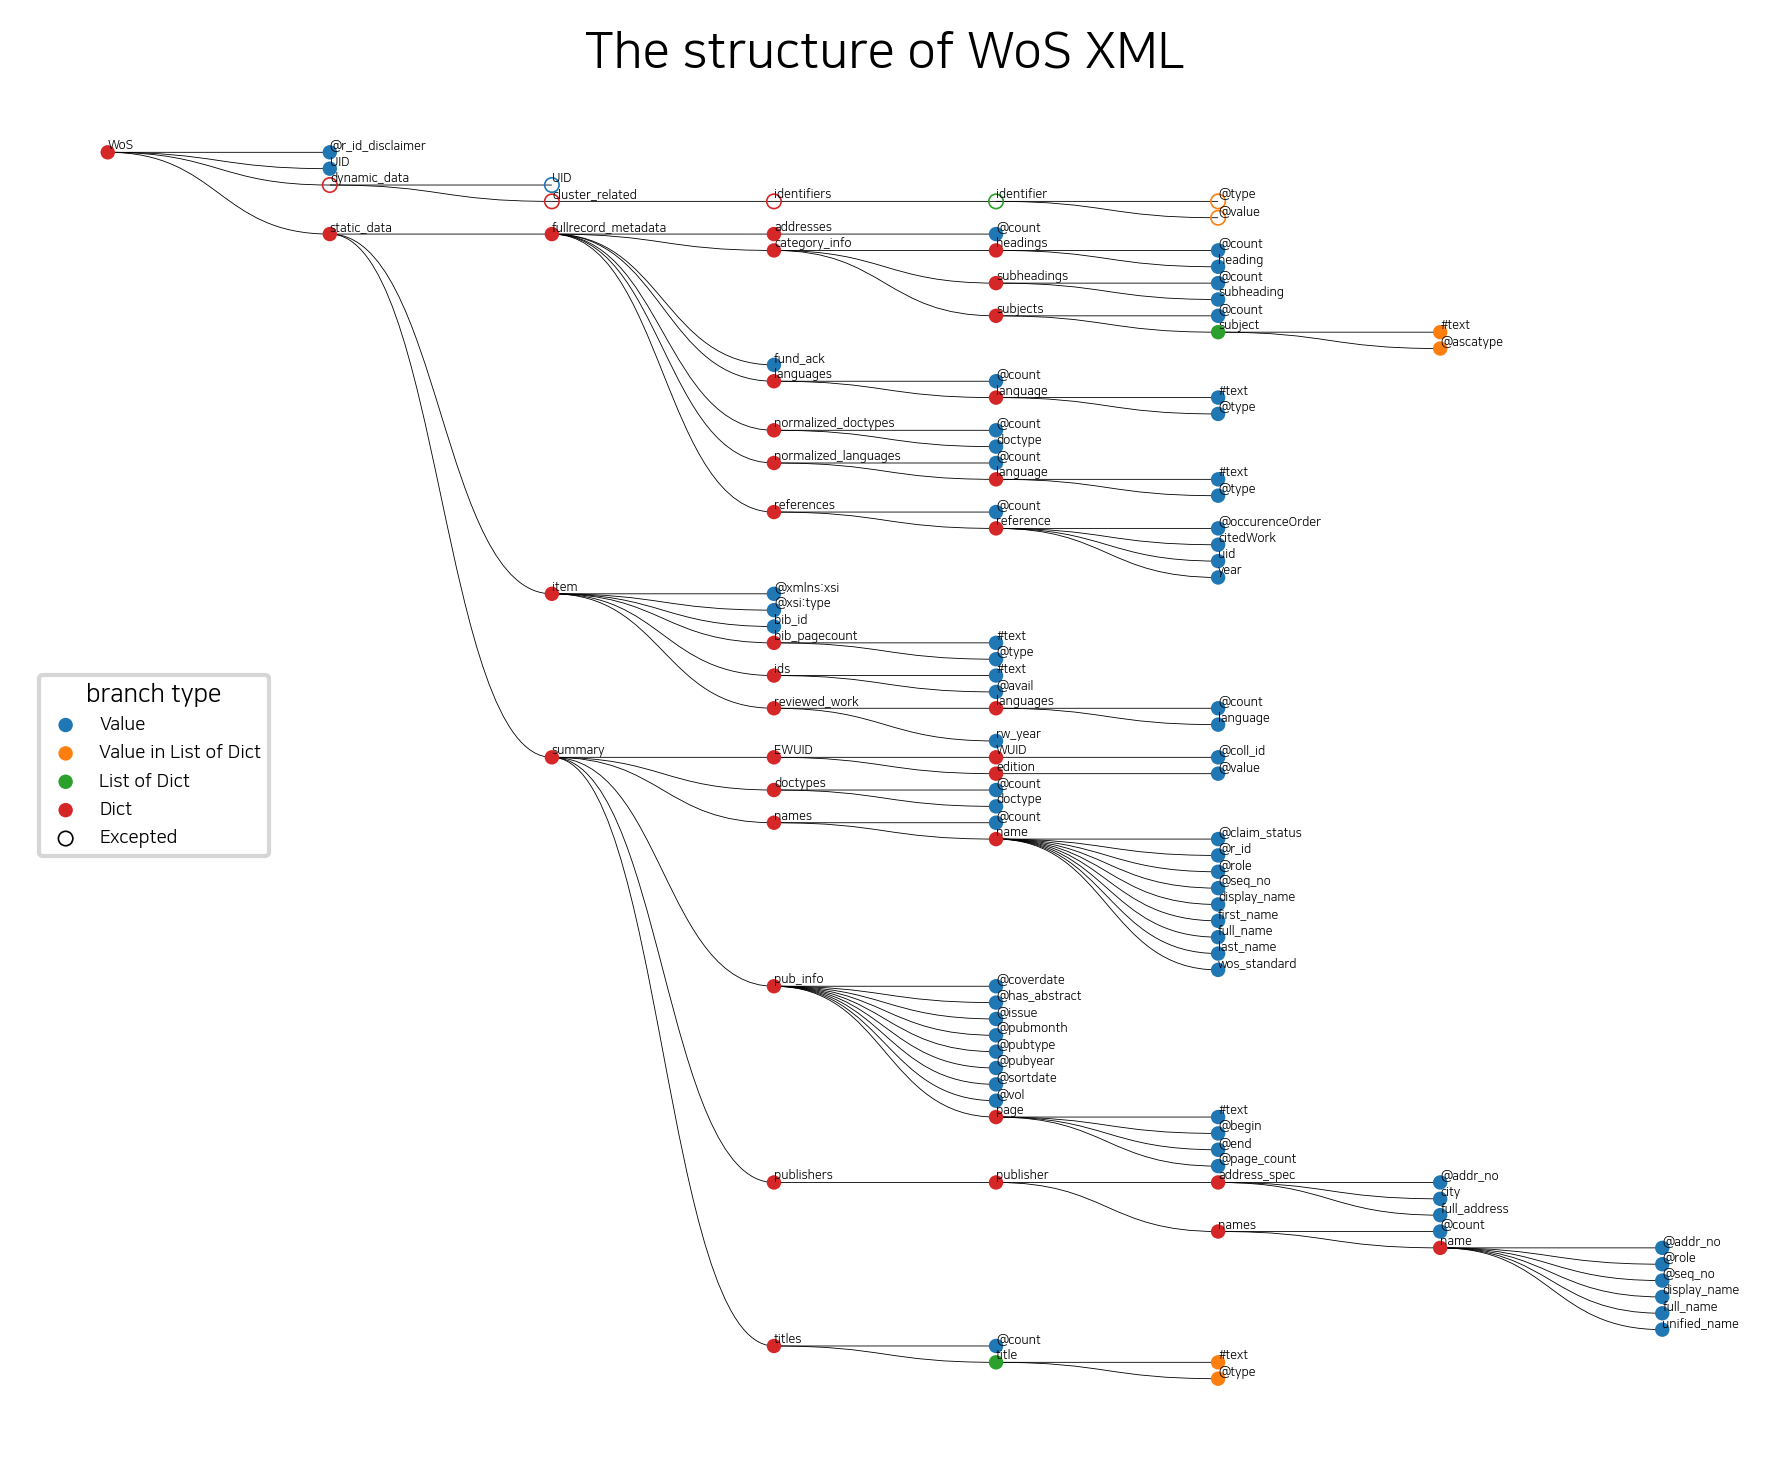

In [909]:
except_keys = ['dynamic_data']
origin = 'WoS'
fig = plot.plot_schema(jsons[0], data_name=origin, origin=origin, except_keys=except_keys, forced={},
          # legend_loc='center left', node_size=12, font_size=3, X_SIZE=6, Y_SIZE=5, DPI=300
                )
plt.tight_layout()
plt.savefig("Structure_WoS_XML.svg")

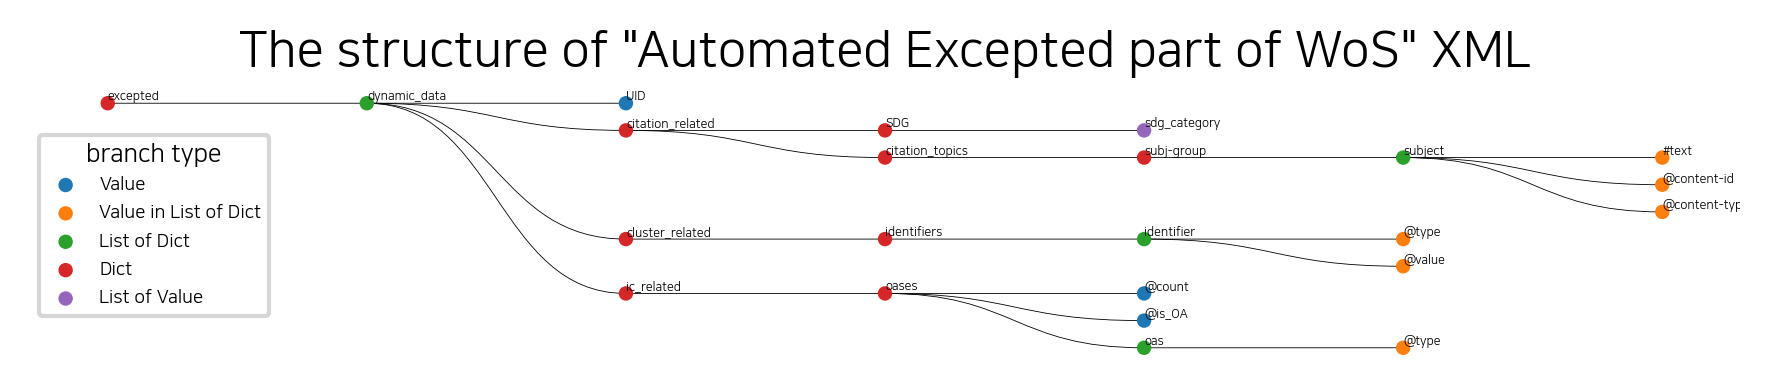

In [908]:
forced = {
    'excepted__dynamic_data__citation_related': 'Dict',
    'excepted__dynamic_data__cluster_related': 'Dict',
    'excepted__dynamic_data__ic_related': 'Dict',
    'excepted__dynamic_data__UID': 'Value',
}
data_name = '"Automated Excepted part of WoS"'
origin = 'excepted'
fig = plot.plot_schema(excepted_part, data_name=data_name, origin=origin, forced=forced,
          legend_loc='bottom left', node_size=12, font_size=3, X_SIZE=6, Y_SIZE=1.4, DPI=300
                )
plt.tight_layout()
plt.savefig("Structure_WoS_XML_Excepted.svg")

In [656]:
key_pairs = processing.json_to_key_pairs(excepted_part, origin)
key_pairs = processing.key_pair_to_df(key_pairs, True, forced=forced) # without unique_set, Multiple and Single is appear twice
types = key_pairs.set_index('branch')['type']

# Set the base_key
# This example is only one excepted field.
# If two excepted field is contained, the module can be unstable.
for ekey in except_keys:
    base_key = f'{origin}{sep}{except_keys[0]}'
    excepted_reg = processing.excepted_regularization(excepted_part[ekey], types, base_key=base_key)
    df_ex, df_ex_subs, excepted_part2 = processing.extract_data_from_jsons(excepted_reg, index_key)

100%|████████████████████████████████████| 51167/51167 [02:42<00:00, 315.35it/s]


In [833]:
data_config = {
    'PATH': 'Data_Sample/',
    'KEY': 'UID',
    'SEP': '__',
    'table_name': 'WoS_Sample'
}

processing.save_data([df, df_subs, df_ex, df_ex_subs], data_config)

'Data_Sample/01__WoS_Sample__MN.ftr' is successfully saved.
'Data_Sample/02__WoS_Sample__MN-SUB__static_data__summary__titles__title.ftr' is successfully saved.
'Data_Sample/03__WoS_Sample__MN-SUB__static_data__fullrecord_metadata__category_info__subjects__subject.ftr' is successfully saved.
'Data_Sample/04__WoS_Sample__EX.ftr' is successfully saved.
'Data_Sample/05__WoS_Sample__EX-SUB__ic_related__oases__oas.ftr' is successfully saved.
'Data_Sample/06__WoS_Sample__EX-SUB__cluster_related__identifiers__identifier.ftr' is successfully saved.
'Data_Sample/07__WoS_Sample__EX-SUB__citation_related__SDG__sdg_category.ftr' is successfully saved.
'Data_Sample/08__WoS_Sample__EX-SUB__citation_related__citation_topics__subj-group__subject.ftr' is successfully saved.


In [834]:
# From here, the SEP means separation for the tabular file like 'csv'
data_config = {
    'PATH': 'Data_Sample/',
    'KEY': 'UID',
    'SEP': '__',
    'table_name': 'WoS_Sample',
    'Conv_DATETIME': False,
}

params = dict(Extra_ratio=1.5, 
              Min_Year=1900, 
              Max_Year=2100, 
              unique_ratio_th=.5, 
              freq_ratio_th=1e-3)

PATH = data_config['PATH']
flist = sorted([x for x in os.listdir(PATH) if '.ftr' in x])
df_descs = []
for f in flist:
    data_config = preview.update_data_config(f, data_config)
    df_desc = preview.get_Table_Description(data_config, params)
    df_descs.append(df_desc)

Generate the Description file for table `01__WoS_Sample__MN`
Generate the Description file for table `02__WoS_Sample__MN-SUB__static_data__summary__titles__title`
Generate the Description file for table `03__WoS_Sample__MN-SUB__static_data__fullrecord_metadata__category_info__subjects__subject`
Generate the Description file for table `04__WoS_Sample__EX`
Generate the Description file for table `05__WoS_Sample__EX-SUB__ic_related__oases__oas`
Generate the Description file for table `06__WoS_Sample__EX-SUB__cluster_related__identifiers__identifier`
Generate the Description file for table `07__WoS_Sample__EX-SUB__citation_related__SDG__sdg_category`
Generate the Description file for table `08__WoS_Sample__EX-SUB__citation_related__citation_topics__subj-group__subject`


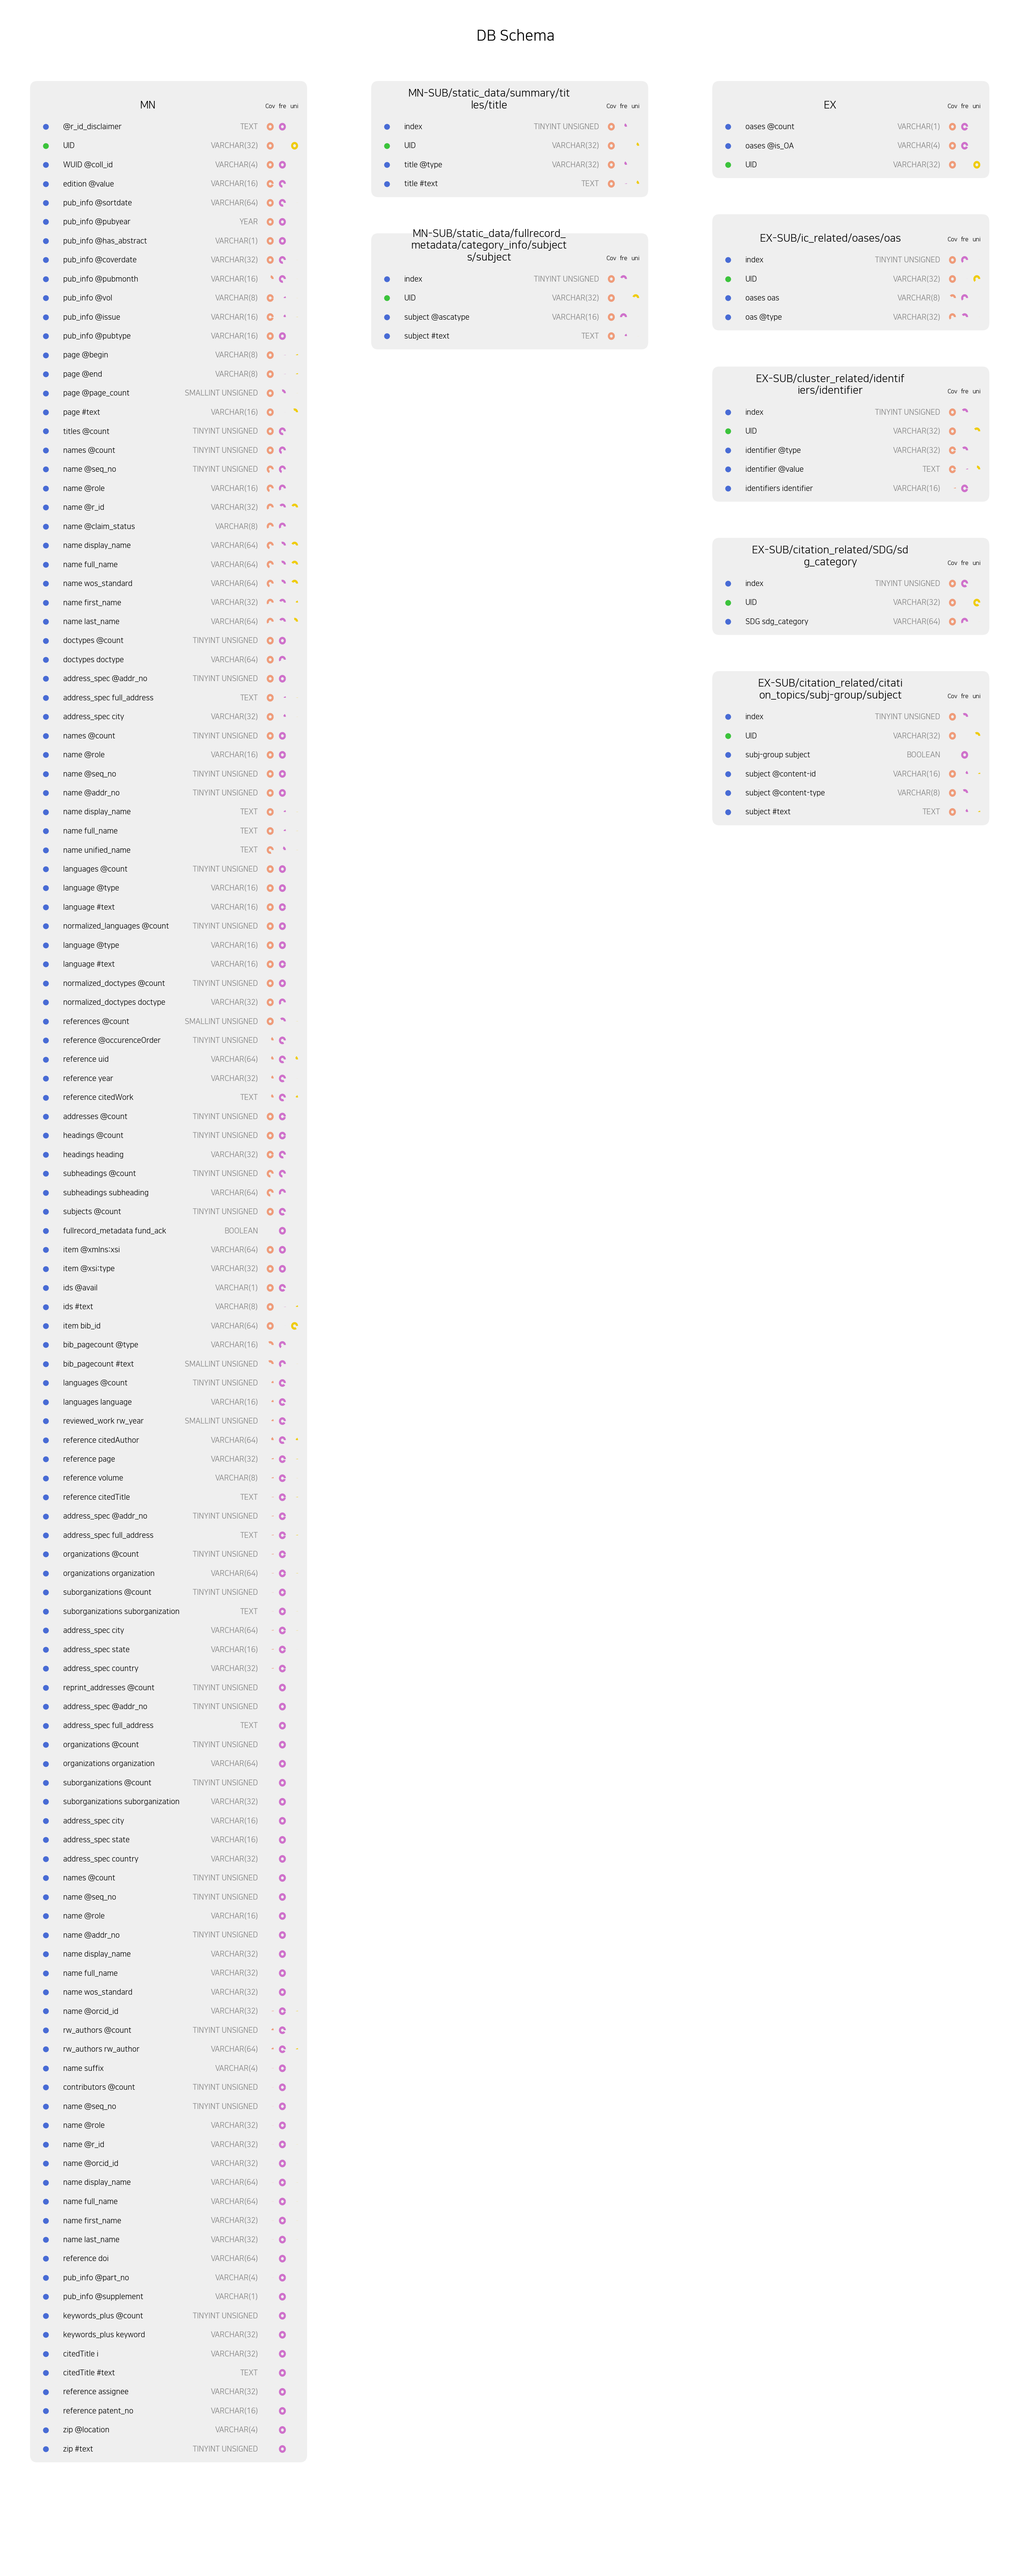

In [904]:
# legend_loc='center left', node_size=12, font_size=3, X_SIZE=6, Y_SIZE=5, DPI=300
legend_loc='center left'
node_size=8
font_size=5
X_SIZE=10
Y_SIZE=24
DPI=300

import matplotlib.patches as mpatches
from matplotlib.patches import Wedge

def write_item():
    x = x_base
    y = y_base-i
    # name = idx.split(sep)[-1]
    
    name = " ".join(idx.split(sep)[-2:])
    type = df_desc.loc[idx, 'Type']
    fts = df_desc.loc[idx, features]
    colors = ['lightsalmon', 'orchid', 'gold']
    color = 'royalblue'
    if name == index_key:
        color = 'limegreen'
    
    plt.scatter(x, y, s=node_size, c=color)
    plt.text(x+x_unit, y, name, ha='left', va='center', fontdict=dict(fontsize=font_size)) # Name
    plt.text(x+x_unit+table_unit*.8, y, type, ha='right', va='center', color='grey', fontdict=dict(fontsize=font_size)) # Type
    # Coverage, freq, uniq_ratio
    for j, v in enumerate(fts):
        _wedge = mpatches.Wedge((x+x_unit+table_unit*(.85 + 0.05*j), y), 0.2, 0, 360*v, width=0.12, ec="none", fc=colors[j])
        ax.add_artist(_wedge)


def split_title_line(title_text, max_words=24):  # , max_words=None):
    """
    A function that splits any string based on specific character
    (returning it with the string), with maximum number of words on it
    """
    splited = []
    text = title_text[:]
    while text != '':
        splited.append(text[:max_words])
        text = text[max_words:]
    return '\n'.join(splited)


def base_set(x_base, y_base, fi, max_words):
    f = flist[fi]
    table_name = "/".join(f.split('/')[-1].split('__')[2:])[:-4]
    table_name = split_title_line(table_name, max_words=max_words)
    
    if (table_name == 'EX') | (fi == 1):
        x_base += table_unit*1.4
        y_base = 0
    elif fi != 0:
        y_base -= i+5
    plt.text(x_base+table_unit*.42, y_base+1, table_name, ha='center', fontdict=dict(fontsize=font_size*1.4))
    for j, v in enumerate(features):
        plt.text(x_base+x_unit+table_unit*(.85 + 0.05*j), y_base+1, v[:3], ha='center', fontdict=dict(fontsize=font_size*.8))
    return x_base, y_base


def set_bbox():
    box = mpatches.FancyBboxPatch((x_base-x_unit*.5, y_base-i-.3), table_unit*1.08, i+2.3, ec="none", fc='grey', alpha=.12,
                            boxstyle=mpatches.BoxStyle("Round", pad=.4))
    ax.add_artist(box)

title='DB Schema'
sep='__'
x_unit=1
table_unit = x_unit*14
features = ['Coverage', 'freq', 'uniq_ratio']


N_ROW = 1
N_COL = 1
plt.rcParams['font.family'] = ['NanumSquare', 'Helvetica']
# plt.rcParams['font.family'] = ['Helvetica', 'NanumSquare']

# plt.rcParams['svg.fonttype'] = 'path'
plt.rcParams['svg.fonttype'] = 'none'
#svg.fonttype : 'path'         # How to handle SVG fonts:
#    'none': Assume fonts are installed on the machine where the SVG will be viewed.
#    'path': Embed characters as paths -- supported by most SVG renderers
#    'svgfont': Embed characters as SVG fonts -- supported only by Chrome,
#               Opera and Safari


fig=plt.figure(figsize = (X_SIZE*N_COL,Y_SIZE*N_ROW), dpi=DPI)
spec = gridspec.GridSpec(ncols=N_COL, nrows=N_ROW, figure=fig, )#, width_ratios=[1,1,.1], wspace=.3)
axes = []
axi=0
ax = fig.add_subplot(spec[axi//N_COL,axi%N_COL]) # row, col
########### Draw ###########
x_base, y_base = 0, 0
patches = []
for fi, df_desc in enumerate(df_descs):
    x_base, y_base = base_set(x_base, y_base, fi, max_words=30)
    for i, idx in enumerate(df_desc.index):
        write_item() ## a line
    set_bbox()

plt.xlim([-x_unit*2, table_unit*4])

plt.tight_layout()
plt.axis('off')
plt.title(title, y=0.985, fontdict=dict(fontsize=font_size*2))

plt.savefig("test.svg")

# Excepted branch

## Consider Excepted part
- accumulate the date
    - single > multiple
    - couverage checing
    - coloring
    - optimizion

In [ ]:
data_config = {
    'PATH': 'Data_Sample/',
    'SEP': ',',
    'file_name': 'file_name', # Dummy init value
    'file_type': 'csv', # Dummy init value
    'table_name': 'table_name', # Dummy init value for Exporting
    'out_path': '../Data/SQL/', # Update as needed
    'Conv_DATETIME': False,
}

In [20]:
PATH = '../Data/Funding/KR_NTIS/'
SEP = '\t'
Port = 0 # Port for DB with host
CHARACTER_SET = 'utf8mb4'
COLLATE = 'utf8mb4_unicode_520_ci'

params = dict(Extra_ratio=1.5, 
              Min_Year=1900, 
              Max_Year=2100, 
              unique_ratio_th=.5, 
              freq_ratio_th=1e-3)

db_config = {
    'host': 'localhost',  # Update as needed
    'user': 'user',       # Update as needed
    'password': '1234',       # Update as needed
    'database': 'KR_NTIS_2023_raw'  # Update as needed
}

data_config = {
    'PATH': PATH,
    'SEP': SEP,
    'file_name': 'file_name', # Dummy init value
    'file_type': 'csv', # Dummy init value
    'table_name': 'table_name', # Dummy init value for Exporting
    'out_path': '../Data/SQL/', # Update as needed
    'Conv_DATETIME': False,
}

In [ ]:
manage.init_MySQL()
try:
    manage.drop_DB(db_config['database'], db_config)
except:
    pass
manage.create_DB(db_config['database'], CHARACTER_SET, COLLATE, db_config)


# Generate the Tabular File list
flist = sorted([x for x in os.listdir(PATH) if 'raw.ftr' in x])
for f in tqdm(flist[:]):
    data_config = preview.update_data_config(f, data_config)
    df_desc = preview.get_Table_Description(data_config, params)
    
    # Generate and execute CREATE TABLE SQL
    manage.create_table(data_config, db_config)
    manage.fill_table_from_file(data_config, db_config)
    manage.set_index(db_config, data_config)
    manage.optimize_table(db_config, data_config)

 * Starting MySQL database server mysqld
   ...done.
Failed to drop database `KR_NTIS_2023_raw`. Error: (1049, "Unknown database 'KR_NTIS_2023_raw'")
Database `KR_NTIS_2023_raw` created successfully.


  0%|                                                    | 0/16 [00:00<?, ?it/s]

Generate the Description file for table `1_Projects_raw`
Table `1_Projects_raw` created successfully.
Data inserted into table `1_Projects_raw` successfully.
Set Index the 과제고유번호 on `1_Projects_raw` successfully.


In [ ]:
manage.backup_database_subprocess(db_config, data_config)

In [81]:
_df_subs.keys()

dict_keys(['static_data__summary__titles__title', 'static_data__summary__names__name', 'static_data__fullrecord_metadata__references__reference', 'static_data__fullrecord_metadata__category_info__subjects__subject', 'dynamic_data__citation_related__citation_topics__subj-group__subject'])